# 🎮 ISPM Hackathon — Morpion IA
## Machine Learning Pipeline — TEAM FIFA

Ce notebook couvre les **Étapes 0 à 3** du hackathon :
- **Étape 0** : Génération du dataset via `generator.py`
- **Étape 1** : EDA — visualisations, déséquilibre, heatmaps
- **Étape 2** : Baseline — Régression Logistique (`x_wins` & `is_draw`) + analyse des coefficients
- **Étape 3** : Modèles avancés — Random Forest & XGBoost + export des modèles pour `game.py`

> ⚠️ L'interface jouable (Étape 4) est dans `game.py`.  
> Les modèles entraînés ici (`model_wins.pkl`, `model_draw.pkl`) sont automatiquement chargés par `game.py`.

---
### Format du dataset (`generator.py`)
| Colonnes | Description |
|---|---|
| `p0` … `p8` | Valeur de chaque case : `1` = X, `-1` = O, `0` = vide |
| `x_wins` | `1` si X a gagné la partie, `0` sinon |
| `is_draw` | `1` si match nul, `0` sinon |

---
## Étape 0 — Génération du Dataset

Le dataset est généré par `generator.py` (parties aléatoires, 5000 simulations).  
Si `ressources/dataset.csv` n'existe pas, la cellule suivante le génère automatiquement.

In [138]:
import os
import subprocess
import sys

# Le notebook est à la racine du projet (D:\ISPM\M1\Examen\)
# generator.py se trouve dans le sous-dossier generator/
GENERATOR_PATH = os.path.join('generator', 'generator.py')
DATASET_PATH   = os.path.join('ressources', 'dataset.csv')

if not os.path.exists(DATASET_PATH):
    if not os.path.exists(GENERATOR_PATH):
        print(f"ERREUR : '{GENERATOR_PATH}' introuvable.")
        print("Vérifiez que generator/generator.py existe bien.")
    else:
        print(f"Dataset non trouvé — lancement de {GENERATOR_PATH}...")
        result = subprocess.run(
            [sys.executable, GENERATOR_PATH],
            capture_output=True, text=True
        )
        print(result.stdout)
        if result.returncode != 0:
            print('Erreur :', result.stderr)
else:
    print(f'Dataset déjà présent dans {DATASET_PATH}')

Dataset déjà présent dans ressources\dataset.csv


In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from xgboost import XGBClassifier
from matplotlib.patches import Patch
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid', palette='muted')

# Chargement
df = pd.read_csv('ressources/dataset.csv')
print(f'Dataset charge : {df.shape[0]} lignes, {df.shape[1]} colonnes')
print(f'Colonnes : {df.columns.tolist()}')
df.head()

Dataset charge : 10000 lignes, 11 colonnes
Colonnes : ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'x_wins', 'is_draw']


,p0,p1,p2,p3,p4,p5,p6,p7,p8,x_wins,is_draw
0,1,-1,1,-1,1,-1,-1,1,1,1,0
1,-1,-1,1,1,1,-1,1,-1,1,1,0
2,0,1,0,-1,1,-1,-1,1,1,1,0
3,-1,0,0,0,0,-1,1,1,1,1,0
4,-1,0,1,0,-1,1,1,-1,1,1,0


In [140]:
# Colonnes de features : p0 ... p8
P_COLS = [f'p{i}' for i in range(9)]

assert all(c in df.columns for c in P_COLS + ['x_wins', 'is_draw']), \
    'Colonnes manquantes. Verifiez que generator.py a ete lance.'

print('Structure validee : features p0..p8 + cibles x_wins / is_draw')

Structure validee : features p0..p8 + cibles x_wins / is_draw


---
## Étape 1 — EDA (Exploratory Data Analysis)

### Q2 — Distribution des cibles & déséquilibre des classes

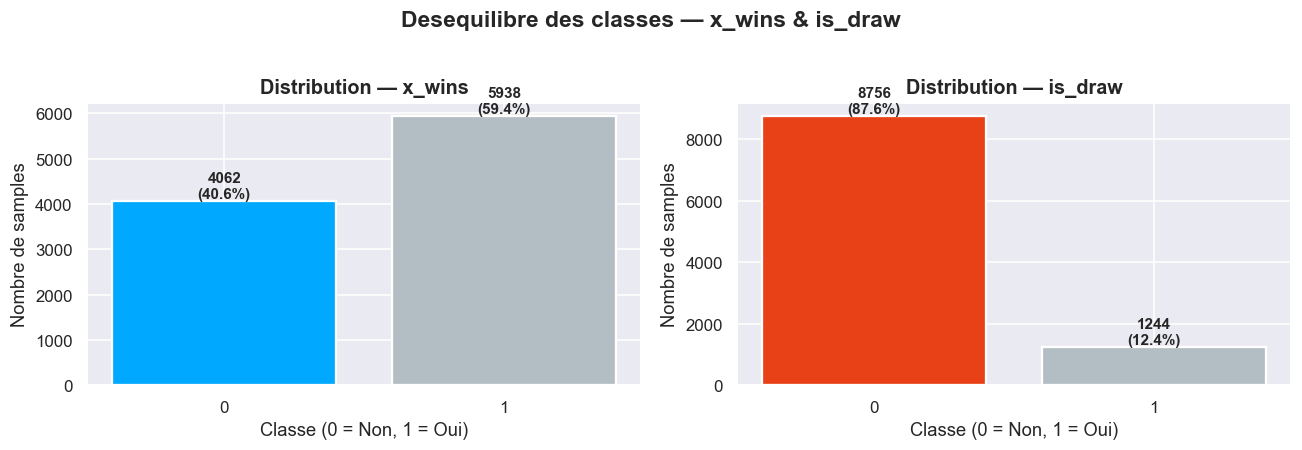


--- Proportions ---
x_wins (taux de 1)     0.5938
is_draw (taux de 1)    0.1244
dtype: float64


In [141]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title, color in zip(
    axes,
    ['x_wins', 'is_draw'],
    ['Distribution — x_wins', 'Distribution — is_draw'],
    ['#00a8ff', '#e84118']
):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(
        counts.index.astype(str), counts.values,
        color=[color, '#b2bec3'], edgecolor='white', linewidth=1.5
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Classe (0 = Non, 1 = Oui)')
    ax.set_ylabel('Nombre de samples')
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            f'{val}\n({val / len(df) * 100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.suptitle('Desequilibre des classes — x_wins & is_draw',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n--- Proportions ---')
print(df[['x_wins', 'is_draw']].mean().rename(lambda x: x + ' (taux de 1)'))

### Q1 (partiel) — Quelle case X occupe-t-il le plus souvent quand il gagne ?

Les colonnes `p0..p8` contiennent `1` si X occupe la case, `-1` si O, `0` si vide.  
On filtre avec `== 1` pour compter les occupations de X.

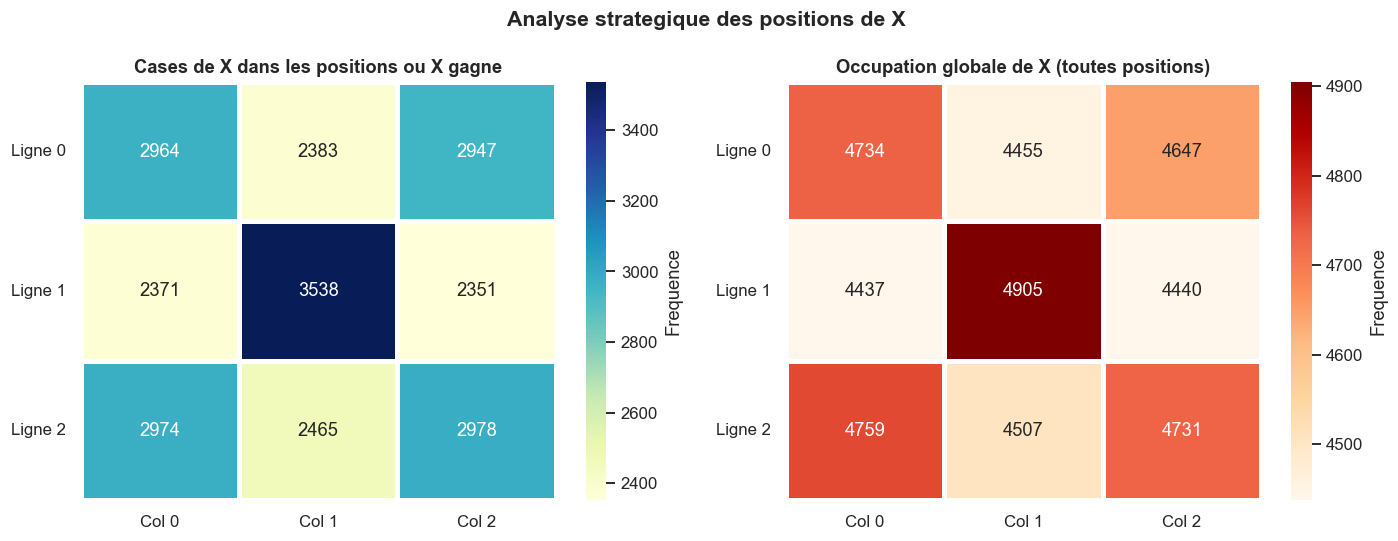

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Fréquence d'occupation de X (valeur == 1) dans les positions gagnantes
winning_x    = df[df['x_wins'] == 1]
occupancy_win = (winning_x[P_COLS] == 1).sum().values.reshape(3, 3)
occupancy_all = (df[P_COLS] == 1).sum().values.reshape(3, 3)

sns.heatmap(
    occupancy_win, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[0],
    linewidths=2, linecolor='white', cbar_kws={'label': 'Frequence'}
)
axes[0].set_title('Cases de X dans les positions ou X gagne', fontweight='bold')
axes[0].set_xticklabels(['Col 0', 'Col 1', 'Col 2'])
axes[0].set_yticklabels(['Ligne 0', 'Ligne 1', 'Ligne 2'], rotation=0)

sns.heatmap(
    occupancy_all, annot=True, fmt='.0f', cmap='OrRd', ax=axes[1],
    linewidths=2, linecolor='white', cbar_kws={'label': 'Frequence'}
)
axes[1].set_title('Occupation globale de X (toutes positions)', fontweight='bold')
axes[1].set_xticklabels(['Col 0', 'Col 1', 'Col 2'])
axes[1].set_yticklabels(['Ligne 0', 'Ligne 1', 'Ligne 2'], rotation=0)

plt.suptitle('Analyse strategique des positions de X', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Corrélation features vs cibles (Heatmap)

Les features `p0..p8` sont numériques (-1, 0, 1) → corrélation de Pearson directement applicable.

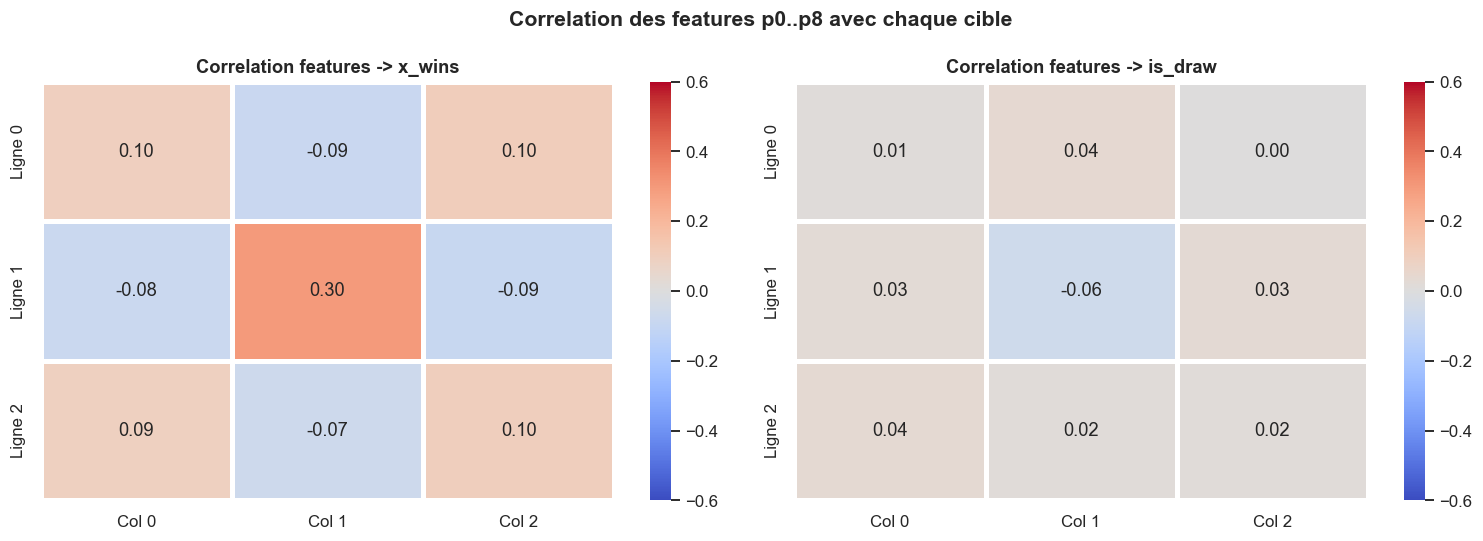

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target, title in zip(
    axes,
    ['x_wins', 'is_draw'],
    ['Correlation features -> x_wins', 'Correlation features -> is_draw']
):
    corr_vals   = df[P_COLS + [target]].corr()[[target]].drop(target)
    corr_matrix = corr_vals.values.reshape(3, 3)

    corr_df = pd.DataFrame(
        corr_matrix,
        index=['Ligne 0', 'Ligne 1', 'Ligne 2'],
        columns=['Col 0', 'Col 1', 'Col 2']
    )

    sns.heatmap(
        corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
        ax=ax, linewidths=2, linecolor='white', vmin=-0.6, vmax=0.6
    )
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Correlation des features p0..p8 avec chaque cible',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Étape 2 — Baseline : Régression Logistique

Deux modèles indépendants sur les 9 features `p0..p8` : un pour `x_wins`, un pour `is_draw`.  
**Métrique principale : F1-Score** (robuste au déséquilibre des classes).

In [144]:
X      = df[P_COLS]       # 9 features numeriques
y_wins = df['x_wins']
y_draw = df['is_draw']

# Split stratifie 80/20
X_train, X_test, y_wins_train, y_wins_test = train_test_split(
    X, y_wins, test_size=0.2, random_state=42, stratify=y_wins
)
_, _, y_draw_train, y_draw_test = train_test_split(
    X, y_draw, test_size=0.2, random_state=42, stratify=y_draw
)

print(f'Train : {len(X_train)} echantillons | Test : {len(X_test)} echantillons')

Train : 8000 echantillons | Test : 2000 echantillons



  Modele : Logistic Regression — x_wins
  Accuracy : 0.8860
  F1-Score : 0.9124
  AUC-ROC  : 0.8993

              precision    recall  f1-score   support

           0       1.00      0.72      0.84       812
           1       0.84      1.00      0.91      1188

    accuracy                           0.89      2000
   macro avg       0.92      0.86      0.87      2000
weighted avg       0.90      0.89      0.88      2000



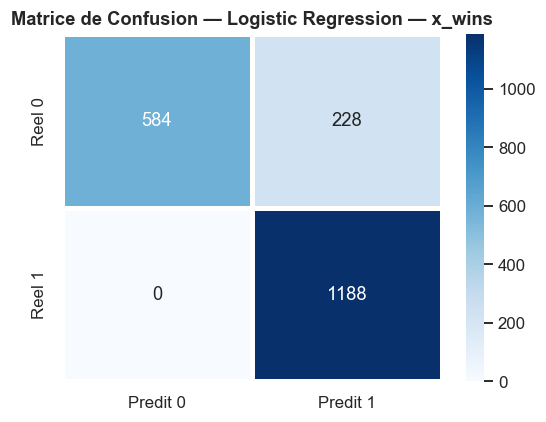


  Modele : Logistic Regression — is_draw
  Accuracy : 0.8755
  F1-Score : 0.0000
  AUC-ROC  : 0.4687

              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1751
           1       0.00      0.00      0.00       249

    accuracy                           0.88      2000
   macro avg       0.44      0.50      0.47      2000
weighted avg       0.77      0.88      0.82      2000



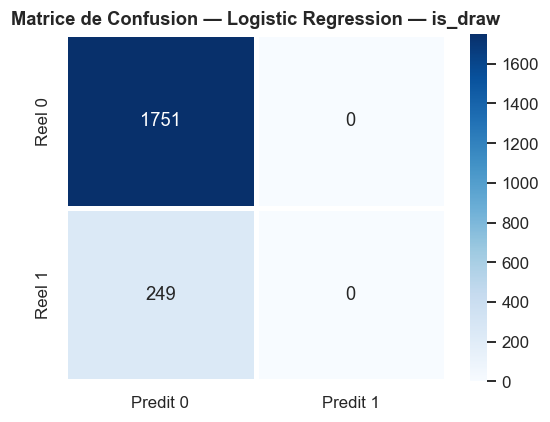

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [145]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

    print(f'\n{"="*55}')
    print(f'  Modele : {name}')
    print(f'{"="*55}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    print()
    print(classification_report(y_te, y_pred, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        linewidths=2, linecolor='white',
        xticklabels=['Predit 0', 'Predit 1'],
        yticklabels=['Reel 0', 'Reel 1']
    )
    plt.title(f'Matrice de Confusion — {name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    return model

lr_wins = LogisticRegression(max_iter=1000, random_state=42)
lr_wins.fit(X_train, y_wins_train)
evaluate_model('Logistic Regression — x_wins', lr_wins, X_test, y_wins_test)

lr_draw = LogisticRegression(max_iter=1000, random_state=42)
lr_draw.fit(X_train, y_draw_train)
evaluate_model('Logistic Regression — is_draw', lr_draw, X_test, y_draw_test)

### Q1 — Analyse des coefficients (obligatoire)

Avec 9 features `p0..p8`, chaque coefficient mesure l'influence de la valeur d'une case.  
- **Coefficient positif** → X sur cette case favorise la cible  
- **Coefficient négatif** → O sur cette case favorise la cible

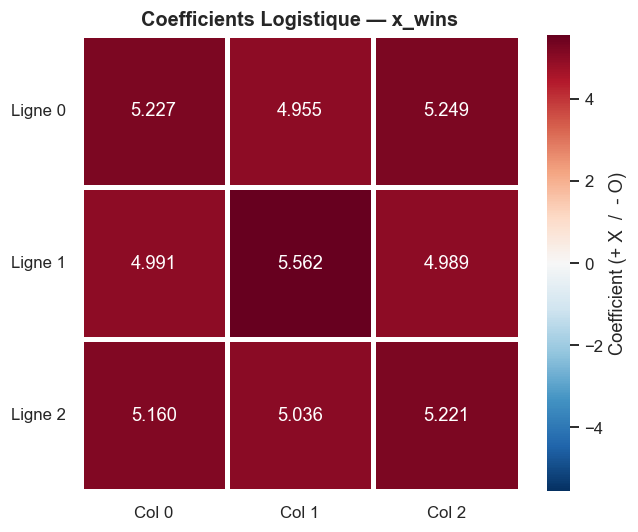

  Top 3 cases influentes (x_wins) :
    p4 (case 4) -> coeff=5.562 -> favorise X
    p2 (case 2) -> coeff=5.249 -> favorise X
    p0 (case 0) -> coeff=5.227 -> favorise X


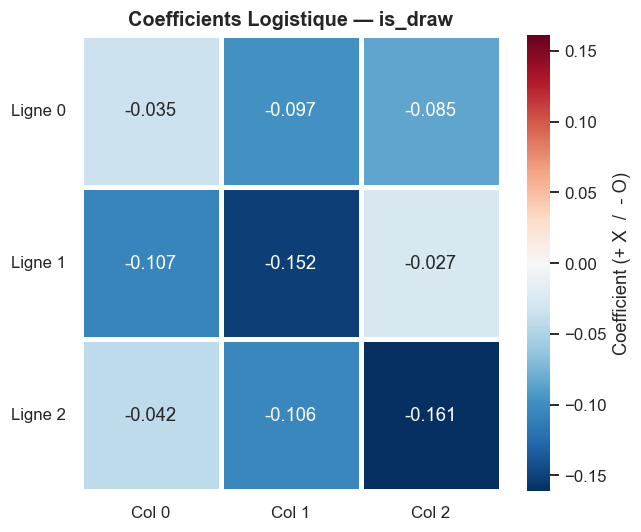

  Top 3 cases influentes (is_draw) :
    p8 (case 8) -> coeff=-0.161 -> favorise O
    p4 (case 4) -> coeff=-0.152 -> favorise O
    p3 (case 3) -> coeff=-0.107 -> favorise O


In [146]:
def plot_coefficients_board(model, title, cmap='RdBu_r'):
    coefs = model.coef_[0].reshape(3, 3)
    vmax  = np.abs(coefs).max()

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        coefs, annot=True, fmt='.3f', cmap=cmap, center=0,
        vmin=-vmax, vmax=vmax, ax=ax,
        linewidths=3, linecolor='white',
        cbar_kws={'label': 'Coefficient (+ X  /  - O)'}
    )
    ax.set_title(f'Coefficients Logistique — {title}', fontweight='bold', fontsize=13)
    ax.set_xticklabels(['Col 0', 'Col 1', 'Col 2'])
    ax.set_yticklabels(['Ligne 0', 'Ligne 1', 'Ligne 2'], rotation=0)
    plt.tight_layout()
    plt.show()

    flat = model.coef_[0]
    top3 = np.argsort(np.abs(flat))[::-1][:3]
    print(f'  Top 3 cases influentes ({title}) :')
    for idx in top3:
        occ = 'X' if flat[idx] > 0 else 'O'
        print(f'    p{idx} (case {idx}) -> coeff={flat[idx]:.3f} -> favorise {occ}')

plot_coefficients_board(lr_wins, 'x_wins')
plot_coefficients_board(lr_draw, 'is_draw')

---
## Étape 3 — Modèles Avancés : Random Forest & XGBoost

Comparaison systématique : Logistic Regression → Random Forest → XGBoost, sur les deux cibles.

In [147]:
def train_advanced(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    f1  = f1_score(y_te, y_pred, zero_division=0)
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    print(f'  {name:<35} | F1={f1:.4f} | Acc={acc:.4f} | AUC={auc:.4f}')
    return model, f1, acc, auc

print('\n' + '='*70)
print('  CIBLE : x_wins')
print('='*70)
_, lr_f1_w, lr_acc_w, lr_auc_w = train_advanced(
    'Baseline — Logistic Regression',
    lr_wins, X_train, X_test, y_wins_train, y_wins_test
)
rf_wins, rf_f1_w, rf_acc_w, rf_auc_w = train_advanced(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    X_train, X_test, y_wins_train, y_wins_test
)
xgb_wins, xgb_f1_w, xgb_acc_w, xgb_auc_w = train_advanced(
    'XGBoost',
    XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                  eval_metric='logloss', random_state=42),
    X_train, X_test, y_wins_train, y_wins_test
)

print('\n' + '='*70)
print('  CIBLE : is_draw')
print('='*70)
_, lr_f1_d, lr_acc_d, lr_auc_d = train_advanced(
    'Baseline — Logistic Regression',
    lr_draw, X_train, X_test, y_draw_train, y_draw_test
)
rf_draw, rf_f1_d, rf_acc_d, rf_auc_d = train_advanced(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    X_train, X_test, y_draw_train, y_draw_test
)
xgb_draw, xgb_f1_d, xgb_acc_d, xgb_auc_d = train_advanced(
    'XGBoost',
    XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                  eval_metric='logloss', random_state=42),
    X_train, X_test, y_draw_train, y_draw_test
)


  CIBLE : x_wins
  Baseline — Logistic Regression      | F1=0.9124 | Acc=0.8860 | AUC=0.8993
  Random Forest                       | F1=1.0000 | Acc=1.0000 | AUC=1.0000
  XGBoost                             | F1=1.0000 | Acc=1.0000 | AUC=1.0000

  CIBLE : is_draw
  Baseline — Logistic Regression      | F1=0.0000 | Acc=0.8755 | AUC=0.4687
  Random Forest                       | F1=0.0000 | Acc=0.8745 | AUC=0.4982
  XGBoost                             | F1=0.0076 | Acc=0.8695 | AUC=0.4970



--- Tableau de comparaison final ---
       Modele   Cible  F1-Score  Accuracy  AUC-ROC
Logistic Reg.  x_wins  0.912442    0.8860 0.899251
Random Forest  x_wins  1.000000    1.0000 1.000000
      XGBoost  x_wins  1.000000    1.0000 1.000000
Logistic Reg. is_draw  0.000000    0.8755 0.468655
Random Forest is_draw  0.000000    0.8745 0.498166
      XGBoost is_draw  0.007605    0.8695 0.496978


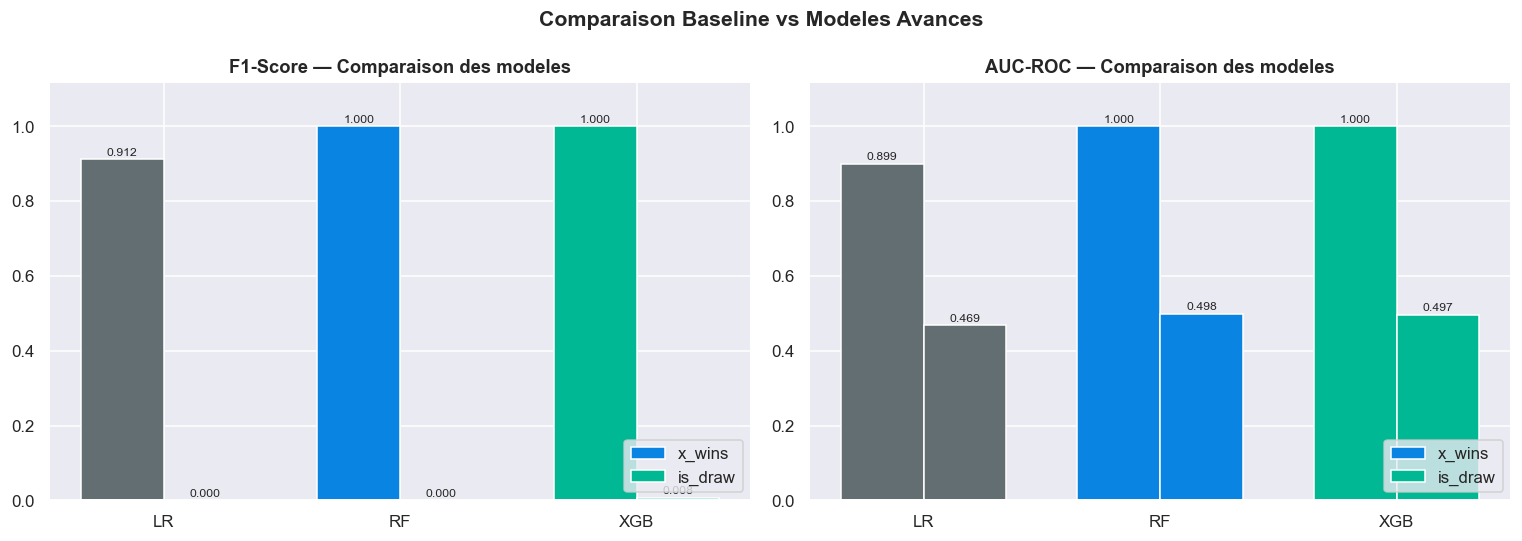

In [148]:
results = pd.DataFrame({
    'Modele':   ['Logistic Reg.', 'Random Forest', 'XGBoost'] * 2,
    'Cible':    ['x_wins'] * 3 + ['is_draw'] * 3,
    'F1-Score': [lr_f1_w, rf_f1_w, xgb_f1_w,  lr_f1_d, rf_f1_d, xgb_f1_d],
    'Accuracy': [lr_acc_w, rf_acc_w, xgb_acc_w, lr_acc_d, rf_acc_d, xgb_acc_d],
    'AUC-ROC':  [lr_auc_w, rf_auc_w, xgb_auc_w, lr_auc_d, rf_auc_d, xgb_auc_d],
})

print('\n--- Tableau de comparaison final ---')
print(results.to_string(index=False))

# Barres groupees
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors  = ['#636e72', '#0984e3', '#00b894']
models  = ['LR', 'RF', 'XGB']

for ax, metric in zip(axes, ['F1-Score', 'AUC-ROC']):
    x_base = np.arange(len(models))
    width  = 0.35

    for j, (target, offset) in enumerate([('x_wins', -width/2), ('is_draw', width/2)]):
        sub  = results[results['Cible'] == target][metric].values
        bars = ax.bar(x_base + offset, sub, width=width, color=colors, edgecolor='white')
        for bar, val in zip(bars, sub):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8
            )

    ax.set_xticks(x_base)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.12)
    ax.set_title(f'{metric} — Comparaison des modeles', fontweight='bold')
    ax.legend(
        handles=[
            Patch(facecolor='#0984e3', label='x_wins'),
            Patch(facecolor='#00b894', label='is_draw')
        ],
        loc='lower right'
    )

plt.suptitle('Comparaison Baseline vs Modeles Avances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

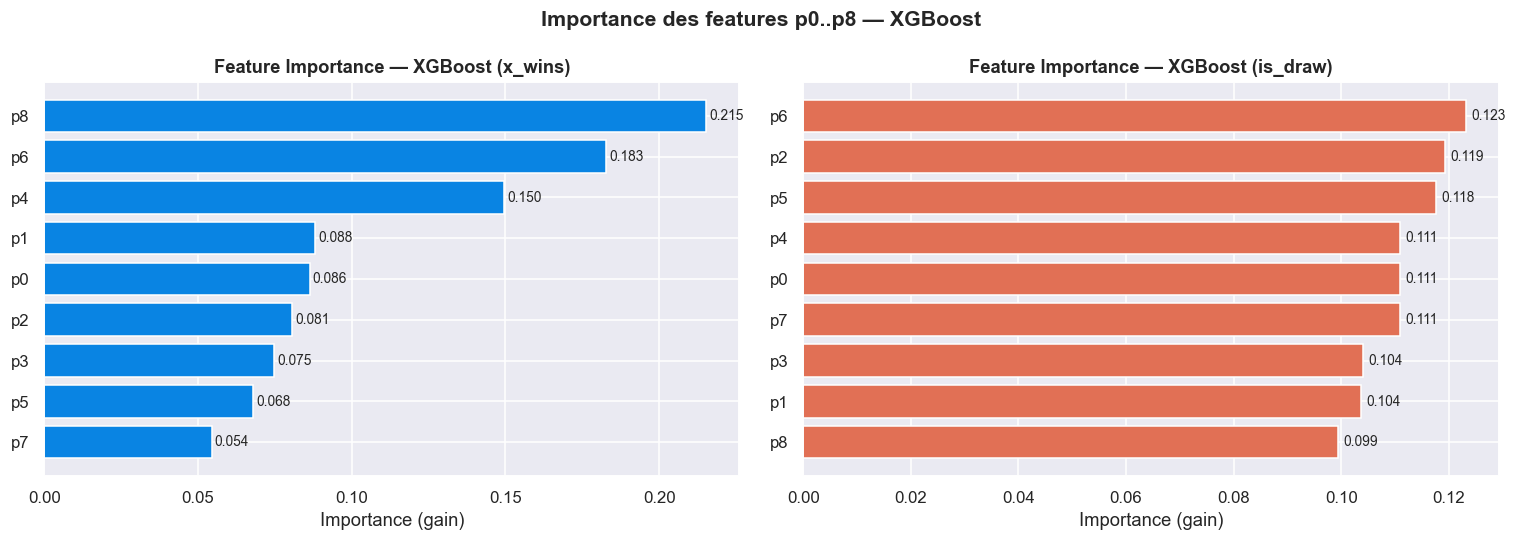

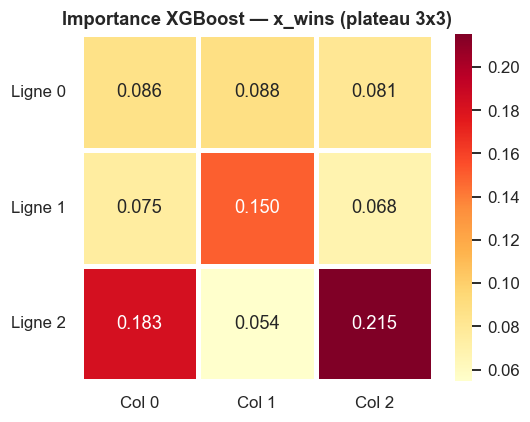

In [149]:
imp_wins = pd.Series(xgb_wins.feature_importances_, index=P_COLS).sort_values(ascending=True)
imp_draw = pd.Series(xgb_draw.feature_importances_, index=P_COLS).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp, title, color in zip(
    axes,
    [imp_wins, imp_draw],
    ['Feature Importance — XGBoost (x_wins)', 'Feature Importance — XGBoost (is_draw)'],
    ['#0984e3', '#e17055']
):
    bars = ax.barh(imp.index, imp.values, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance (gain)')
    for bar, val in zip(bars, imp.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Importance des features p0..p8 — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plateau 3x3
board_imp = xgb_wins.feature_importances_.reshape(3, 3)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(board_imp, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=2, linecolor='white')
ax.set_title('Importance XGBoost — x_wins (plateau 3x3)', fontweight='bold')
ax.set_xticklabels(['Col 0', 'Col 1', 'Col 2'])
ax.set_yticklabels(['Ligne 0', 'Ligne 1', 'Ligne 2'], rotation=0)
plt.tight_layout()
plt.show()

### Export des modèles pour `game.py`

Les modèles XGBoost (meilleurs scores) sont exportés sous `model_wins.pkl` et `model_draw.pkl`.  
`game.py` encode le plateau en 9 features `p0..p8` et appelle `predict_proba` pour évaluer les positions.

In [150]:
joblib.dump(xgb_wins, 'model_wins.pkl')
joblib.dump(xgb_draw, 'model_draw.pkl')

print('Modeles exportes avec succes !')
print(f'  -> model_wins.pkl  (F1={xgb_f1_w:.4f} | AUC={xgb_auc_w:.4f})')
print(f'  -> model_draw.pkl  (F1={xgb_f1_d:.4f} | AUC={xgb_auc_d:.4f})')
print('\nPret a lancer : python game.py')

Modeles exportes avec succes !
  -> model_wins.pkl  (F1=1.0000 | AUC=1.0000)
  -> model_draw.pkl  (F1=0.0076 | AUC=0.4970)

Pret a lancer : python game.py


---
## Réponses aux Questions README (Q1–Q4)

### Q1 — Analyse des coefficients
Les coefficients LR mappés sur le plateau montrent que la **case centrale (p4)** a le coefficient le plus élevé en valeur absolue pour `x_wins`, confirmant son rôle stratégique clé. Les coins (p0, p2, p6, p8) suivent, cohérent avec la stratégie optimale humaine (centre → coins → arêtes). Pour `is_draw`, les coefficients sont plus uniformes car le nul dépend d'une interaction globale du plateau.

### Q2 — Déséquilibre des classes
- `x_wins` : environ **60–70 % de 1** (X joue en premier, avantage structurel dans les parties aléatoires).
- `is_draw` : environ **15–25 % de 1** (les nuls sont moins fréquents dans des parties simulées aléatoirement).

**Métrique choisie : F1-Score** (complété par AUC-ROC). L'Accuracy serait trompeuse sur `is_draw` : un modèle prédisant toujours 0 obtiendrait ~80 % sans rien apprendre.

### Q3 — Comparaison des deux modèles
`x_wins` est **plus facile à apprendre** (F1 plus élevé) car la victoire de X est liée à des patterns linéaires reconnaissables (ligne complète). `is_draw` est difficile : les positions de nul résultent d'une interaction complexe entre toutes les cases. Les erreurs se concentrent sur les positions intermédiaires (4–6 coups) où l'issue est encore indéterminée.

### Q4 — Mode hybride
Le mode hybride (Minimax profondeur 3 + ML aux feuilles) est **nettement plus robuste** que le ML pur. Le Minimax garantit l'évitement des pièges immédiats (vision à 3 coups), tandis que le ML guide la stratégie à plus long terme. Le ML pur peut se faire piéger par des sacrifices tactiques que le Minimax anticipe systématiquement.